# <p style="text-align:center;"> **Task 2**</p>

In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Data Cleaning**

First we will load in the scraped data so we can inspect it and identify any entries that need to be cleaned


In [333]:
# Load in the scraped data
df_raw = pd.read_csv("retail_raw.csv")

The following cells give us an overview of the raw data

In [334]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       1900 non-null   object 
 1   sale_date     1900 non-null   object 
 2   category      1900 non-null   object 
 3   quantity      1900 non-null   int64  
 4   total_price   1900 non-null   float64
 5   total_profit  1900 non-null   float64
 6   payment_type  1900 non-null   object 
 7   customer_id   1900 non-null   int64  
 8   location      1900 non-null   object 
 9   gender        1900 non-null   object 
 10  age_band      1889 non-null   object 
 11  year          1900 non-null   int64  
 12  quarter       1900 non-null   int64  
 13  page          1900 non-null   int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 207.9+ KB


In [335]:
df_raw.describe(include="all")

,product,sale_date,category,quantity,total_price,total_profit,payment_type,customer_id,location,gender,age_band,year,quarter,page
count,1900,1900,1900,1900.000000,1900.000000,1900.000000,1900,1900.000000,1900,1900,1889,1900.0,1900.000000,1900.000000
unique,98,356,42,NaN,NaN,NaN,9,NaN,26,5,67,NaN,NaN,NaN
top,Blue Floral Embroidered Mac,2025-12-10,Children — Girls Clothing,NaN,NaN,NaN,Credit Card,NaN,Dublin,Female,Category 25-34,NaN,NaN,NaN
freq,57,12,380,NaN,NaN,NaN,903,NaN,603,719,121,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.567368,52.348368,22.516937,NaN,9610.744211,NaN,NaN,NaN,2025.0,2.515263,8.426316
std,NaN,NaN,NaN,1.121943,52.369199,19.927423,NaN,5374.742135,NaN,NaN,NaN,0.0,1.108766,4.579454
min,NaN,NaN,NaN,-1.000000,6.750000,3.080000,NaN,1000.000000,NaN,NaN,NaN,2025.0,1.000000,1.000000
25%,NaN,NaN,NaN,1.000000,29.000000,11.600000,NaN,5086.250000,NaN,NaN,NaN,2025.0,2.000000,4.000000
50%,NaN,NaN,NaN,1.000000,35.000000,17.590000,NaN,8962.000000,NaN,NaN,NaN,2025.0,3.000000,8.000000
75%,NaN,NaN,NaN,2.000000,58.000000,26.500000,NaN,14114.500000,NaN,NaN,NaN,2025.0,4.000000,12.000000


From the above table we can see:  
9 unique types of `payment_type` but there should only be 4: Credit card, Debit card, Voucher and Paypal    
5 unique `gender`types, there should only be 3: Male, Female or Prefer not to say.   
67 unique `age_bands`, there should only be 7: 18-24, 25-34, 35-44, 45-54, 55-64, 65+ and None   

The `sale_date` column also needs to be converted from text object to datetime format so that analysis can be performed.

In the `product` and `category` data spaces and dashes are inconsistent, so any double spaces need to be changed to single spaces and dashes should be standarised to `-` instead of `—`.  

Some quantity values are -1,  but the sale and profit values are not negative. We will take these to mean a return.

In [336]:
# Create the cleaned version of the data
df_clean = df_raw.copy()

### Payment type cleaning

Before cleaning the different payment types that appear are:

In [337]:
print(df_raw["payment_type"].unique())

['Credit Card' 'Debit Card' 'CC' 'PayPal' 'Voucher' 'Debit  Card'
 'Credit  Card' 'Pay  Pal' 'Pay Pal']


To clean this category we can make the following replacements so that the only categories are Credit Card, Debit Card, Paypal and Voucher only.

In [338]:
# replace CC, and double spaced entries with their corresponding entries
df_clean["payment_type"] = (
    df_raw["payment_type"]
    .astype(str)
    .str.strip()
    .replace({
        "CC": "Credit Card",
        "Credit  Card": "Credit Card",
        "Debit  Card": "Debit Card",
        "Pay Pal": "PayPal",
        "Pay  Pal": "PayPal",
    })
)
# check we have only 4
print (df_clean["payment_type"].unique())

['Credit Card' 'Debit Card' 'PayPal' 'Voucher']


### Gender cleaning

Before cleaning, the different types of gender that appear are:

In [339]:
print(df_raw["gender"].unique())

['Female' 'F' 'Male' 'Prefer not to say' 'M']


To clean this category we can make the following replacements so that the categories are Female, Male and Prefer not to say.

In [340]:
# replace M with Male and F with Female
df_clean["gender"] = (
    df_raw["gender"]
    .astype(str)
    .str.strip()
    .replace({
        "F": "Female",
        "M": "Male",
    })
)
# check we have only 3
print(df_clean["gender"].unique())

['Female' 'Male' 'Prefer not to say']


### Age Band Cleaning

Before cleaning the different Age bands are:

In [341]:
df_raw["age_band"].unique()

array(['Range 25-34', 'Group 35—44', 'Category 55—64', 'Range 35-44',
       'Group 35-44', 'Group 45-54', 'Range 18-24', 'Category 35-44',
       'Category 25-34', '25–34', '18-24', 'Range 55-64', '35–44',
       'Group 25-34', nan, 'Range 35—44', 'Category 18–24',
       'Category 55-64', 'Group 18-24', 'Group 25–34', '55-64',
       'Category 18—24', '25-34', 'Range 25—34', '45—54', 'Group 55–64',
       'Group 65+', 'Category 65+', '45-54', '35-44', 'Category 25–34',
       'Range 25–34', 'Group 18—24', 'Category 35—44', 'Category 35–44',
       'Group 45—54', 'Group 45–54', '55–64', 'Group 18–24', '55—64',
       'Category 45-54', 'Range None', '65+', '18–24', 'Category 25—34',
       'Category 18-24', 'Range 45-54', 'Group 35–44', 'Range 45–54',
       'Range 18—24', '35—44', 'Category 45—54', 'Group 55-64',
       'Range 55—64', '45–54', '18—24', 'Category 55–64', 'Group 25—34',
       '25—34', 'Group 55—64', 'Range 35–44', 'Group None', 'Range 18–24',
       'Range 45—54', 'Cat

Here the number of options is too large to do a replacement, so instead we will remove the Range/Category/Group from each entry as well as standardise the dashes to use `-` rather than `—` or `–`

In [342]:
# remove Range/Category/Group and replace double spaces and dashes
df_clean["age_band"] = (
    df_raw["age_band"]
    .fillna("None") # For the 11 missing values we saw above
    .astype(str)
    .str.strip()
    .str.replace("Range ", "")
    .str.replace("Group ", "")
    .str.replace("Category ", "")
    .str.replace("–", "-")
    .str.replace("—", "-")
)
# check we have only 7 types
print(df_clean["age_band"].unique())

['25-34' '35-44' '55-64' '45-54' '18-24' 'None' '65+']


### Sale Date changes
Convert from text object to datetime format for easier analysis


In [343]:
df_clean["sale_date"] = pd.to_datetime(df_raw["sale_date"])

### Product and Category Cleaning
Before cleaning there were 98 unique products and 42 unique categories from the table above

In [344]:
df_clean["product"] = (
    df_raw["product"]
    .astype(str)
    .str.strip()
    .str.replace("—", "-")
    .str.replace("–", "-")
    .str.replace("  ", " ")
)

df_clean["category"] = (
    df_raw["category"]
    .astype(str)
    .str.strip()
    .str.replace("—", "-")
    .str.replace("–", "-")
    .str.replace("  ", " ")
)

print(f'Now we have {df_clean["product"].nunique()} unique products and {df_clean["category"].nunique()} unique categories')

Now we have 95 unique products and 11 unique categories


We also want to reflect the returns in the profit and revenue data as they are currently stored as positive profit/revenue.

In [345]:
# Create signed revenue and profit
df_clean['net_revenue'] = df_clean['total_price'] * np.where(df_clean['quantity'] < 0, -1, 1)
df_clean['net_profit'] = df_clean['total_profit'] * np.where(df_clean['quantity'] < 0, -1, 1)

Now we can see below that the data has been cleaned and is now ready for analysis.

In [346]:
df_clean.describe(include="all")

,product,sale_date,category,quantity,total_price,total_profit,payment_type,customer_id,location,gender,age_band,year,quarter,page,net_revenue,net_profit
count,1900,1900,1900,1900.000000,1900.000000,1900.000000,1900,1900.000000,1900,1900,1900,1900.0,1900.000000,1900.000000,1900.000000,1900.000000
unique,95,NaN,11,NaN,NaN,NaN,4,NaN,26,3,7,NaN,NaN,NaN,NaN,NaN
top,Blue Floral Embroidered Mac,NaN,Children - Girls Clothing,NaN,NaN,NaN,Credit Card,NaN,Dublin,Female,25-34,NaN,NaN,NaN,NaN,NaN
freq,57,NaN,446,NaN,NaN,NaN,1059,NaN,603,1000,665,NaN,NaN,NaN,NaN,NaN
mean,NaN,2025-07-01 22:16:55.578947328,NaN,1.567368,52.348368,22.516937,NaN,9610.744211,NaN,NaN,NaN,2025.0,2.515263,8.426316,51.256053,22.030547
min,NaN,2025-01-01 00:00:00,NaN,-1.000000,6.750000,3.080000,NaN,1000.000000,NaN,NaN,NaN,2025.0,1.000000,1.000000,-57.000000,-27.930000
25%,NaN,2025-04-04 18:00:00,NaN,1.000000,29.000000,11.600000,NaN,5086.250000,NaN,NaN,NaN,2025.0,2.000000,4.000000,29.000000,11.512500
50%,NaN,2025-07-02 00:00:00,NaN,1.000000,35.000000,17.590000,NaN,8962.000000,NaN,NaN,NaN,2025.0,3.000000,8.000000,35.000000,17.590000
75%,NaN,2025-10-01 00:00:00,NaN,2.000000,58.000000,26.500000,NaN,14114.500000,NaN,NaN,NaN,2025.0,4.000000,12.000000,58.000000,26.425000
max,NaN,2025-12-23 00:00:00,NaN,10.000000,445.000000,169.600000,NaN,19562.000000,NaN,NaN,NaN,2025.0,4.000000,17.000000,445.000000,169.600000


## **Data Analysis**

### Overview Statistics

In [347]:
# Some quick overview statistics
n_customers = df_clean["customer_id"].nunique()
total_revenue = df_clean["net_revenue"].sum()
total_profit = df_clean["net_profit"].sum()
total_units = df_clean["quantity"].sum()
returns = (df_clean["quantity"] == -1).sum()

print("Unique customers:", n_customers)
print("Net Revenue: €", round(total_revenue,2))
print("Net Profit:  €", round(total_profit,2))
print("Net quantity sold:", total_units)
print("Total Returns:", returns)

Unique customers: 1165
Net Revenue: € 97386.5
Net Profit:  € 41858.04
Net quantity sold: 2978
Total Returns: 29


### Product analysis 
We will summarise the contribution of products to quantity, total revenue and total profit

In [348]:
# Product summary table
product_analysis = (
    df_clean.groupby('product', as_index=False)
    .agg(
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .sort_values('profit', ascending=False)
)

# Top 10 Products by profit 
product_analysis.head(10)

,product,quantity_sold,revenue,profit
22,Cream Vintage Bin,73,5241.60,1825.20
52,Marshall Oxford Shirt,68,4221.00,1564.92
62,Navy Herringbone Throw,45,3987.20,1383.95
81,Soft Velour Eyelet Lined Curtains,32,3392.00,1356.80
9,Black Single Cuff Shirt,83,3465.00,1303.68
33,Floral Embroidered Kaftan,80,2528.00,1273.60
92,White Tie and Shirt Set,96,3342.50,1259.30
43,Lattice Runner,37,3164.80,1255.60
79,Rose Print Prom Dress,63,2319.90,1177.71
18,Blue Stripe Snuggle Fit Pyjamas,125,2295.85,1162.67


The table above shows which products contribute most to profits, with the Cream vintage Bin and Marshall Oxford Shirt being the two standout performers.


### Category Analysis 
Category analysis will give a broad view of sales performance.

In [349]:
# Category summary table
category_analysis = (
    df_clean.groupby('category', as_index=False)
    .agg(
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .sort_values('profit', ascending=False)
)

# Top Categories by profit 
category_analysis

,category,quantity_sold,revenue,profit
1,Children - Girls Clothing,634,14519.70,7349.31
5,Men - Shirts,378,15569.65,5809.92
3,Homeware - Design,410,14412.05,5702.15
4,Men - Jeans,348,12295.20,4822.20
0,Children - Boys Clothing,535,9140.10,4612.43
2,Homeware - Bed Bath,165,11571.15,4004.83
7,Men - Trousers,167,5868.90,2857.35
6,Men - Shoes,128,5869.00,2612.45
10,Women - Tops,106,4366.20,2443.80
8,Women - Dresses,67,2024.95,963.20


This table shows which categories generate the most revenue and profit. But does not show how profitable certain categories are relative to sales numbers, for this we can look at the profit margin.


In [350]:
# Profit margin by category
category_analysis['profit_margin'] = round(category_analysis['profit'] / category_analysis['revenue'], 4)
category_analysis.sort_values('profit_margin', ascending=False)[
    ['category', 'revenue', 'profit', 'profit_margin']
]

,category,revenue,profit,profit_margin
10,Women - Tops,4366.20,2443.80,0.5597
1,Children - Girls Clothing,14519.70,7349.31,0.5062
0,Children - Boys Clothing,9140.10,4612.43,0.5046
7,Men - Trousers,5868.90,2857.35,0.4869
8,Women - Dresses,2024.95,963.20,0.4757
6,Men - Shoes,5869.00,2612.45,0.4451
3,Homeware - Design,14412.05,5702.15,0.3957
4,Men - Jeans,12295.20,4822.20,0.3922
9,Women - Shoes,1749.60,680.40,0.3889
5,Men - Shirts,15569.65,5809.92,0.3732


From the above table we can see that Women's tops and Children's clothes are the most profitable items while Homeware and Mens jeans and shirts are less profitable even though they contributed to more of the total profit from before.

### Sale data Analysis
We can look at how sales vary over the course of the year with the sale date data.

In [351]:
# Monthly summary
monthly_summary = (
    df_clean.groupby(df_clean['sale_date'].dt.month_name(), sort=False)
    .agg(
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .reindex([
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ])
)

monthly_summary

,quantity_sold,revenue,profit
sale_date,,,
January,256,8724.90,3698.90
February,199,6697.10,2859.33
March,249,7933.75,3428.56
April,243,7297.55,3238.42
May,255,8889.75,3841.31
June,279,9364.20,3930.75
July,241,8793.05,3772.90
August,272,7783.00,3520.83
September,228,6875.35,3034.22


We can compare revenue and profit across the year to see if they follow a similar trajectory.

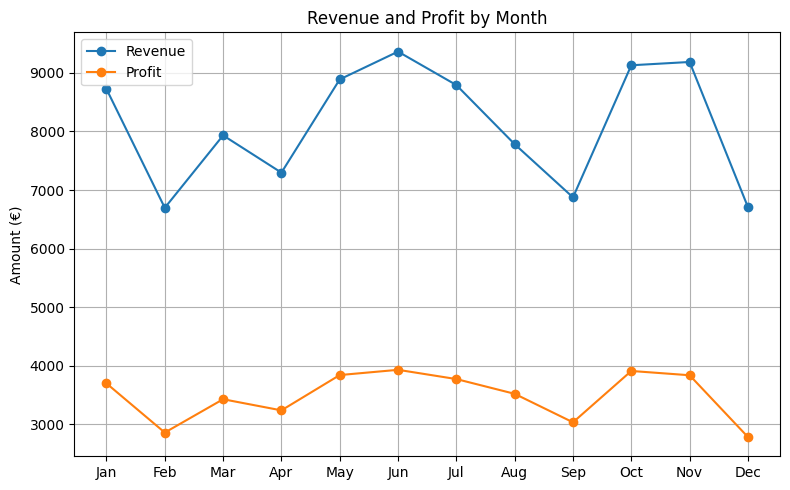

In [352]:
# Monthly revenue and profit on one graph
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(8, 5))
plt.plot(monthly_summary.index, monthly_summary['revenue'], marker='o', label='Revenue')
plt.plot(monthly_summary.index, monthly_summary['profit'], marker='o', label='Profit')
plt.xticks(range(0, 12), months)
plt.ylabel('Amount (€)')
plt.title('Revenue and Profit by Month')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We can see that profit and revenue follow similar trends across the year with peaks in June and October.

### Payment type Analysis
We can look at the frequencies of different payment types.

In [353]:
# Summary by payment type
payment_analysis = (
    df_clean.groupby('payment_type', as_index=False)
    .agg(
        transactions=('payment_type', 'count'),
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .sort_values('transactions', ascending=False)
)

payment_analysis

,payment_type,transactions,quantity_sold,revenue,profit
0,Credit Card,1059,1771,60173.20,25397.75
1,Debit Card,664,945,28723.65,12721.68
2,PayPal,125,188,6181.10,2736.34
3,Voucher,52,74,2308.55,1002.27


The table above shows how each payment method performs across the main sales measures. We can see that Credit cards are the most common compared to Debit cards, this is important as credit card transaction fees are often higher than debit cards fees.

### Location Analysis
We can investigate where in Ireland sales and profit are concentrated.

In [354]:
# Summary by location
location_analysis = (
    df_clean.groupby('location', as_index=False)
    .agg(
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .sort_values('profit', ascending=False)
)
# top 10 locations by profit
location_analysis.head(10)

,location,quantity_sold,revenue,profit
5,Dublin,955,31686.55,13537.44
3,Cork,338,10994.75,4703.23
8,Kildare,180,5549.20,2345.69
6,Galway,132,4841.00,2079.47
12,Limerick,104,3927.25,1684.34
25,Wicklow,121,3835.65,1682.28
21,Tipperary,118,3737.95,1593.36
15,Mayo,106,3572.05,1515.47
4,Donegal,89,2708.50,1185.17
14,Louth,73,2662.95,1143.13


We can see from above that Dublin and Cork are the highest contributors, this was to be expected from population but we can also look at which locations are the best controlling for quantity.

In [355]:
location_analysis['profit_per_unit'] = (
    location_analysis['profit'] / location_analysis['quantity_sold']
)

location_analysis['revenue_per_unit'] = (
    location_analysis['revenue'] / location_analysis['quantity_sold']
)

location_analysis = location_analysis.sort_values('profit_per_unit', ascending=False)
# Top 10 locations by profit per unit
location_analysis.head(10)

,location,quantity_sold,revenue,profit,profit_per_unit,revenue_per_unit
1,Cavan,39,1705.50,741.93,19.023846,43.730769
17,Monaghan,33,1309.50,572.65,17.353030,39.681818
19,Roscommon,32,1318.30,546.40,17.075000,41.196875
12,Limerick,104,3927.25,1684.34,16.195577,37.762019
6,Galway,132,4841.00,2079.47,15.753561,36.674242
14,Louth,73,2662.95,1143.13,15.659315,36.478767
20,Sligo,36,1250.05,524.85,14.579167,34.723611
11,Leitrim,20,646.65,288.51,14.425500,32.332500
15,Mayo,106,3572.05,1515.47,14.296887,33.698585
5,Dublin,955,31686.55,13537.44,14.175330,33.179634


From the above table we can see Cavan, Monaghan and Roscommon were the most profitable Counties per unit sold.

### Demographic Analysis
We will now lok at sales performance across gender and age bands.

In [356]:
# Gender and age band combined
demo_analysis = (
    df_clean.groupby(['gender', 'age_band'], as_index=False)
    .agg(
        quantity_sold=('quantity', 'sum'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
)
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'None']
demo_analysis['age_band'] = pd.Categorical(demo_analysis['age_band'], categories=age_order, ordered=True)
demo_analysis = demo_analysis.sort_values(['profit'], ascending=False)

demo_analysis.head(10)

,gender,age_band,quantity_sold,revenue,profit
1,Female,25-34,560,16941.50,7234.52
2,Female,35-44,469,14061.00,6224.10
8,Male,25-34,409,13227.30,5744.14
9,Male,35-44,286,9759.45,4224.74
0,Female,18-24,264,9693.25,4060.70
7,Male,18-24,213,7099.70,3004.10
3,Female,45-54,199,6462.25,2749.32
10,Male,45-54,139,5136.25,2126.64
11,Male,55-64,108,4278.85,1842.14
4,Female,55-64,100,3375.45,1424.70


From the above table we can see that Women aged 25-44 and Men aged 25-34 were the primary contributors to profit and revenue for the year.

### Profitablily


In [357]:
# Overall profitability measures
total_net_revenue = df_clean['net_revenue'].sum()
total_net_profit = df_clean['net_profit'].sum()
total_units = df_clean['quantity'].abs().sum()

profit_margin = total_net_profit / total_net_revenue
profit_per_unit = total_net_profit / total_units

print("Total Net Revenue: €", total_net_revenue)
print("Total Net Profit: €", round(total_net_profit, 2))
print("Profit Margin:", round(profit_margin,4))
print("Profit per Unit: €", round(profit_per_unit,2))

Total Net Revenue: € 97386.5
Total Net Profit: € 41858.04
Profit Margin: 0.4298
Profit per Unit: € 13.79


In [358]:
# Profitability by month
monthly_profitability = (
    df_clean.groupby(df_clean['sale_date'].dt.month)
    .agg(
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum'),
        units=('quantity', lambda x: x.abs().sum())
    )
)

monthly_profitability['profit_margin'] = monthly_profitability['profit'] / monthly_profitability['revenue']
monthly_profitability['profit_per_unit'] = monthly_profitability['profit'] / monthly_profitability['units']

monthly_profitability

,revenue,profit,units,profit_margin,profit_per_unit
sale_date,,,,,
1,8724.90,3698.90,264,0.423948,14.010985
2,6697.10,2859.33,205,0.426950,13.947951
3,7933.75,3428.56,251,0.432149,13.659602
4,7297.55,3238.42,249,0.443768,13.005703
5,8889.75,3841.31,257,0.432106,14.946732
6,9364.20,3930.75,285,0.419764,13.792105
7,8793.05,3772.90,245,0.429078,15.399592
8,7783.00,3520.83,276,0.452374,12.756630
9,6875.35,3034.22,228,0.441319,13.307982


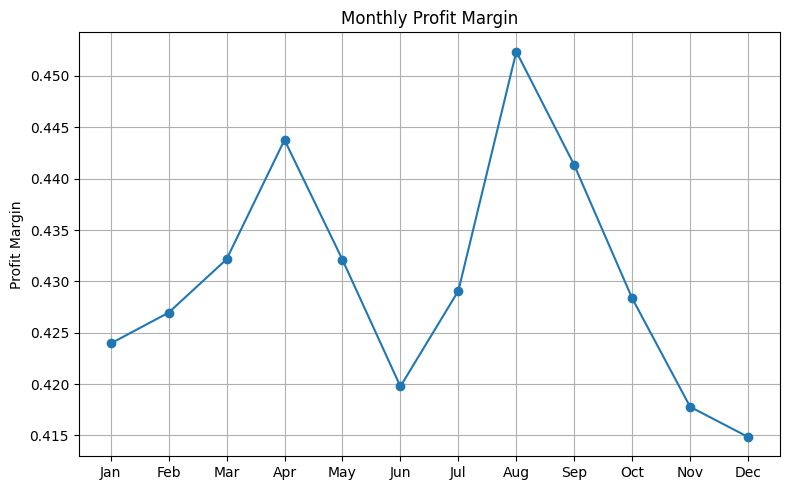

In [359]:
# Monthly profit margin graph
plt.figure(figsize=(8, 5))
plt.plot(monthly_profitability.index, monthly_profitability['profit_margin'], marker='o')
plt.xticks(range(1, 13), months)
plt.ylabel('Profit Margin')
plt.title('Monthly Profit Margin')
plt.tight_layout()
plt.grid(True)
plt.show()

# <p style="text-align:center;"> **Task 3**</p>

The main challenge while collecting the data was that the structure of the website was not uniform across pages and tables, some fields needed extra cleaning after scraping as values were embedded in text blocks rather than stored in a neat tabular format. It was also necessary to handle returns carefully, since returned items were represented by a quantity of -1 but had positive revenue and profit values, which meant the scraped revenue and profit data could not be totalled without adjustment, and net revenue and net profit had to be created so that returns were accounted for. 

The analysis showed that profit and revenue was concentrated in a small number of categories, demographics and locations rather than being spread evenly across the dataset.  The time analysis showed how sales and profitability changed across the year peaking in June and October which was unexpected, while payment type analysis highlighted the most commonly used payment methods and possible costs associated with these methods. Location and demographic analysis showed that customer activity was concentrated in Dublin and Cork among primarily 25-44 year olds.

Further work could make the analysis deeper. Since Dublin dominated total sales, it would be useful to examine the product mix by location, particularly for the high profit per unit counties such as Cavan, Monaghan, and Roscommon, it would be useful  to identify which products or categories are causing the better efficiency. It would also be valuable to compare average order value and profit per transaction by demographics, as we only considered totals. It would also be useful to connect the demographic and location findings, for example by checking whether the strong 25–44 customer segment is concentrated in particular counties.